In [68]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# This is for the graph visualization
from graphviz import Digraph

In [69]:
# starting the Project
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self._prev = set(_children)
        self.data = data
        self._op = _op
        self.grad = 0.0
        self._backward = lambda: None
        self.label = label
        
    def __repr__(self):
        return f"Value(data = {self.data})"
        
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')
        
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
            
        out._backward = _backward
        return out
    def __neg__(self):
        return -1 * self
    def __radd__(self, other): # other + self
        return self + other
    def __sub__(self,other):
        return self + (-other)
        
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')
        
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
            
        out._backward = _backward
        return out
    def __rmul__(self, other):
        return self * other
    def __pow__(self,other):
        assert isinstance(other,(int,float)),f"We Need Only Numbers(int/float) Fella :)"
        out = Value(self.data ** other,(self,),f'**{other}')
        def _backward():
            self.grad += other * (self.data **(other-1)) * out.grad
        out._backward = _backward
        return out
    def __truediv__(self,other):
        return self * other**-1
    def exp(self):
        x = self.data
        out = Value(math.exp(x),(self,),'exp')
        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward
        return out
    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
        out = Value(t, (self,), 'tanh')
        
        def _backward():
            self.grad += (1 - t**2) * out.grad
            
        out._backward = _backward
        return out
        
    # Define backward the Recursive Function
    def backward(self):
        # Create empty list topo and the empty set visited
        topo = []
        visited = set()
        
        # Create Build TOPO function to append to it the children
        def build_topo(v):
            # check if we already looped over v
            if v not in visited:
                # I should add it for the next time
                visited.add(v)
                # Recursion Time
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
                
        # NOW WE BUILD THE TOPO OF THE OUTPUT LAYER
        build_topo(self)
        
        self.grad = 1.0 # THE DERIVATIVE OF THE OUTPUT LAYER WITH RESPECT TO ITSELF IS ALWAYS 1
        
        for node in reversed(topo): # we use Reversed because the output layer will be in the end of topo but we need to start with it
            node._backward()   # Now We calculate the grad from the end to start

In [70]:
from graphviz import Digraph

def trace(root):
    # Builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # Create a rectangular ('record') node for every Value in the graph
        dot.node(name=uid, label="{ %s | data %.4f | grad %.4f }" % (n.label, n.data,n.grad), shape='record')

        if n._op:
            # If this value is a result of an operation (+ or *), create an op node for it
            dot.node(name=uid + n._op, label=n._op)
            # Connect the op node to the actual Value node
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        # Connect the child node to the op node of its parent
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

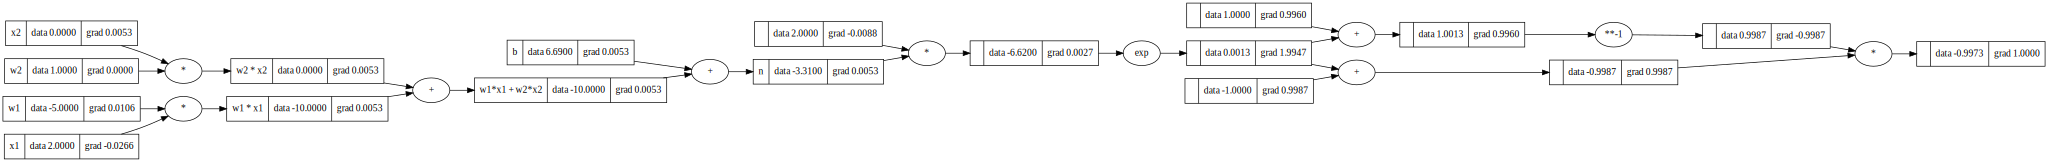

In [71]:
# X values
x1 = Value(2.0 ,label='x1')
x2 = Value(0.0 ,label='x2')
# Weights
w1 = Value(-5.0,label='w1')
w2 = Value(1.0,label='w2')
# Bias
b = Value(6.689999921304,label='b')
# The Function
w1x1 = w1 * x1;w1x1.label='w1 * x1'
w2x2 = w2 * x2;w2x2.label='w2 * x2'
w1x1w2x2 = w1x1 + w2x2;w1x1w2x2.label = 'w1*x1 + w2*x2'
n = w1x1w2x2 + b;n.label='n'
e = (2*n).exp()
o = (e-1)/(e+1)
o.backward()
draw_dot(o)

In [72]:
class Neuron:
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))

    def __call__(self, x):
        # dot product + bias
        act = sum((wi*xi for wi,xi in zip(self.w, x)), self.b)
        return act.tanh()

    def parameters(self):
        return self.w + [self.b]
        
class Layer:
    def __init__(self,nin,nout):
        #List of nout neurons , each of them expect nin inputs
        self.neurons = [Neuron(nin) for _ in range(nout)] 
    def __call__(self,x):
        #pass the inputs to each neuron in this layer
        outs = [n(x) for n in self.neurons]
        return outs[0]if len(outs) == 1 else outs 

    def parameters(self):
        #create a list of all parameters in the layer by looping over all the parameters in each neuron
        return [p for neuron in self.neurons for p in neuron.parameters()]

class MLP:
    def __init__(self,nin,nouts):
        #Adjust the list of nouts(which is the number of neurons in each layer) to start with the number of inputs
        sz = [nin] + nouts
        #Make pairs of each layer and the output of the layer before it which is going to be its input basically
        self.layers = [Layer(sz[i],sz[i+1]) for i in range(len(nouts))]

    def __call__(self,x):
        #for each layer in the different layers
        for layer in self.layers:
            #overrite the inputs with the output of this layer so it be the input of the next layer
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters() ] 


In [73]:
n = MLP(3,[4,4,1])

In [74]:
xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]

ys = [1.0, -1.0, -1.0, 1.0]

In [83]:
for k in range(2000):
    #Forward Pass
    ypred = [n(x) for x in xs]
    loss = sum((yout - ygt)**2 for yout, ygt in zip(ypred, ys))

    #zero the parameters
    for p in n.parameters():
        p.grad = 0.0
    #Backward Pass
    loss.backward()

    #Updating
    for p in n.parameters():
        p.data += -0.1 * p.grad
    print(k,loss.data)

0 5.283986547615922e-06
1 5.283860530274063e-06
2 5.283734518870191e-06
3 5.283608513404977e-06
4 5.28348251387625e-06
5 5.283356520283894e-06
6 5.28323053262823e-06
7 5.28310455090953e-06
8 5.282978575126169e-06
9 5.282852605277923e-06
10 5.282726641364293e-06
11 5.282600683385276e-06
12 5.282474731340213e-06
13 5.282348785228649e-06
14 5.282222845050259e-06
15 5.282096910804373e-06
16 5.281970982490833e-06
17 5.281845060109573e-06
18 5.281719143658967e-06
19 5.281593233140172e-06
20 5.281467328552095e-06
21 5.2813414298936324e-06
22 5.281215537164653e-06
23 5.2810896503658205e-06
24 5.280963769496325e-06
25 5.280837894555117e-06
26 5.280712025541458e-06
27 5.280586162455857e-06
28 5.28046030529749e-06
29 5.280334454066181e-06
30 5.28020860876093e-06
31 5.2800827693821424e-06
32 5.2799569359291464e-06
33 5.279831108400968e-06
34 5.279705286797243e-06
35 5.279579471118706e-06
36 5.279453661363324e-06
37 5.279327857532704e-06
38 5.279202059624236e-06
39 5.279076267639009e-06
40 5.278950

In [84]:
ypred


[Value(data = 0.9992949793031434),
 Value(data = -0.9992324286873678),
 Value(data = -0.9984873896371448),
 Value(data = 0.9987080263637167)]